In [ ]:
!pip install optuna hyperopt xgboost lightgbm catboost bayesian-optimization --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

import optuna
from bayes_opt import BayesianOptimization
from hyperopt import fmin, tpe, hp, Trials
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# Feature Selection
from sklearn.feature_selection import (
    SelectFromModel, RFE, RFECV, SelectKBest, f_regression, mutual_info_regression
)

# Halving Search (sklearn >= 0.24)
from sklearn.experimental import enable_halving_search_cv

from sklearn.model_selection import HalvingGridSearchCV, HalvingRandomSearchCV

In [ ]:
df = pd.read_csv(r'/content/dataset_agrotech_regressao_linear.csv')

In [ ]:
# Encode categóricas
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col])

In [ ]:
# Separação
y = df['produtividade_sacos_ha']
X = df.drop('produtividade_sacos_ha', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
modelos = {
    'Random Forest':        RandomForestRegressor(random_state=42),
    'Gradient Boosting':    GradientBoostingRegressor(random_state=42),
    'AdaBoost':             AdaBoostRegressor(random_state=42),
    'XGBoost':              XGBRegressor(random_state=42, verbosity=0),
    'LightGBM':             LGBMRegressor(random_state=42, verbose=-1),
    'CatBoost':             CatBoostRegressor(random_state=42, verbose=0),
}

resultados_baseline = {}
for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    resultados_baseline[nome] = {'R²': round(r2, 4), 'RMSE': round(rmse, 4)}
    print(f'{nome:<22} R²: {r2:.4f} | RMSE: {rmse:.4f}')

df_baseline = pd.DataFrame(resultados_baseline).T
print('\n Resumo Baseline:')
print(df_baseline.sort_values('R²', ascending=False))

Random Forest - R²: 0.9266
Gradient Boosting - R²: 0.9371
AdaBoost - R²: 0.9092
XGBoost - R²: 0.9237
LightGBM - R²: 0.9312
CatBoost - R²: 0.9395


---
## GridSearchCV — Busca Exaustiva

> **O que é?**  
> O GridSearch testa **todas as combinações possíveis** de hiperparâmetros definidas em uma grade. É o método mais completo, mas também o mais custoso computacionalmente.
>
> **Quando usar?**  
> Quando o espaço de busca é **pequeno** (poucas combinações) ou quando você precisa de **garantia** de encontrar o melhor ponto dentro da grade definida.
>
> **Complexidade:** O(n_params × cv_folds) — cresce rapidamente com o número de combinações.
>
> **Cuidado:** Com 5 parâmetros de 5 valores cada e cv=5, são 5⁵ × 5 = **15.625 treinos**!

In [ ]:
param_grid_rf = {
    'n_estimators':    [100, 200, 300, 400],
    'max_depth':       [5, 10, 15, None],
    'min_samples_split': [2, 5, 7],
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf,
    cv=3,
    scoring='r2',
    n_jobs=-1,         # paraleliza
    verbose=1
)
grid_search.fit(X_train, y_train)

y_pred_grid = grid_search.predict(X_test)
r2_grid = r2_score(y_test, y_pred_grid)

print(f'   Melhores parâmetros: {grid_search.best_params_}')
print(f'   CV R² (treino):     {grid_search.best_score_:.4f}')
print(f'   R² (teste):         {r2_grid:.4f}')
print(f'   Total de fits:      {len(grid_search.cv_results_["params"]) * 3}')

Fitting 3 folds for each of 48 candidates, totalling 144 fits
✅ Melhores parâmetros: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 400}
   CV R² (treino):     0.9304
   R² (teste):         0.9279
   Total de fits:      144


RandomizedSearchCV — Busca Aleatória

> **O que é?**  
> Em vez de testar todas as combinações, o RandomizedSearch **amostra aleatoriamente** `n_iter` configurações do espaço de hiperparâmetros. Isso permite cobrir uma área de busca muito maior com um orçamento fixo.
>
> **Por que funciona bem?**  
> Pesquisas empíricas mostram que, na maioria dos casos, apenas alguns hiperparâmetros realmente importam. Uma busca aleatória tem alta probabilidade de acertar regiões boas sem testar todas as combinações.
>
> **Quando preferir ao GridSearch?**  
> Sempre que o espaço de busca for grande (> 100 combinações) ou quando você quiser explorar distribuições contínuas de valores.

In [ ]:
param_dist_rf = {
    'n_estimators':      np.arange(50, 500, 50),
    'max_depth':         [5, 10, 15, 20, None],
    'min_samples_split': [2, 3, 5, 7, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', None],
}

random_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_dist_rf,
    n_iter=30,         # número de amostras aleatórias
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
random_search.fit(X_train, y_train)

y_pred_rand = random_search.predict(X_test)
r2_rand = r2_score(y_test, y_pred_rand)

print(f'   Melhores parâmetros: {random_search.best_params_}')
print(f'   CV R² (treino):     {random_search.best_score_:.4f}')
print(f'   R² (teste):         {r2_rand:.4f}')
print(f'   Total de fits:      30 × 3 = 90 (vs {len(param_grid_rf["n_estimators"]) * len(param_grid_rf["max_depth"]) * len(param_grid_rf["min_samples_split"]) * 3} do Grid)')

Fitting 3 folds for each of 30 candidates, totalling 90 fits
✅ Melhores parâmetros: {'n_estimators': np.int64(450), 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 15}
   CV R² (treino):     0.9304
   R² (teste):         0.9278
   Total de fits:      30 × 3 = 90 (vs 144 do Grid)


HalvingSearchCV — Eliminação Progressiva *(novo)*

> **O que é?**  
> O Halving Search é um método **multi-fidelidade** inspirado no torneio: começa com muitos candidatos usando **pouco dado**, e vai eliminando os piores pela metade a cada rodada, até o melhor sobrar.
>
> **Vantagem:**  
> Muito mais rápido que GridSearch, pois candidatos ruins são descartados cedo com amostras pequenas.  
> Garante que os melhores candidatos sejam avaliados com dados suficientes.
>
> **Factor:** controla quantos candidatos são eliminados a cada rodada (padrão = 3 → elimina 2/3).
>
> **Quando usar?** Quando você tem um grid grande mas quer economizar tempo de treinamento.

In [ ]:
from sklearn.model_selection import HalvingRandomSearchCV

halving_search = HalvingRandomSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_dist_rf,
    factor=3,           # elimina 2/3 a cada rodada
    resource='n_samples',
    max_resources='auto',
    n_candidates=50,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
halving_search.fit(X_train, y_train)

y_pred_halv = halving_search.predict(X_test)
r2_halv = r2_score(y_test, y_pred_halv)

print(f'   Melhores parâmetros: {halving_search.best_params_}')
print(f'   CV R² (treino):     {halving_search.best_score_:.4f}')
print(f'   R² (teste):         {r2_halv:.4f}')

# Visualizar as rodadas
results_halv = pd.DataFrame(halving_search.cv_results_)
print(f'\n Rodadas do Halving Search:')
print(results_halv.groupby('iter')['mean_test_score'].agg(['mean', 'max', 'count']).round(4))

n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 6
min_resources_: 6
max_resources_: 2400
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 50
n_resources: 6
Fitting 3 folds for each of 50 candidates, totalling 150 fits
----------
iter: 1
n_candidates: 17
n_resources: 18
Fitting 3 folds for each of 17 candidates, totalling 51 fits
----------
iter: 2
n_candidates: 6
n_resources: 54
Fitting 3 folds for each of 6 candidates, totalling 18 fits
----------
iter: 3
n_candidates: 2
n_resources: 162
Fitting 3 folds for each of 2 candidates, totalling 6 fits
   Melhores parâmetros: {'n_estimators': np.int64(250), 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 15}
   CV R² (treino):     0.8334
   R² (teste):         0.9281

 Rodadas do Halving Search:
         mean      max  count
iter                         
0    -45.8087 -29.6762     50
1     -0.8898  -0.2440     17
2      0.6237   0.6784      6
3      0.8317   0.8334    

Optuna — Otimização Bayesiana Moderna

> **O que é?**  
> Optuna é um framework de **AutoML para hiperparâmetros** que usa o algoritmo **TPE (Tree-structured Parzen Estimator)** por padrão. Ele aprende com tentativas anteriores para direcionar a busca para regiões promissoras.
>
> **Diferenciais do Optuna:**
> - **Pruning:** interrompe trials que parecem ruins cedo (economiza tempo)
> - **Define-by-run:** o espaço de busca é definido dinamicamente na função objective
> - **Visualizações:** integração nativa com plots de importância de parâmetros
>
>
> **Quando usar?** Para otimizações complexas onde o espaço tem dependências entre parâmetros.

In [ ]:
def objective_optuna(trial):
    params = {
        'n_estimators':    trial.suggest_int('n_estimators', 50, 500),
        'max_depth':       trial.suggest_int('max_depth', 3, 20),
        'learning_rate':   trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':       trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight':trial.suggest_int('min_child_weight', 1, 10),
        'gamma':           trial.suggest_float('gamma', 0.0, 5.0),
    }
    model = XGBRegressor(**params, random_state=42, verbosity=0)
    #  Usar cross_val_score evita vazamento de dados (data leakage)
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring='r2')
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective_optuna, n_trials=40, show_progress_bar=True)

# Avaliar no teste
best_xgb = XGBRegressor(**study.best_params, random_state=42, verbosity=0)
best_xgb.fit(X_train, y_train)
r2_optuna = r2_score(y_test, best_xgb.predict(X_test))

print(f'\n Melhores parâmetros: {study.best_params}')
print(f'   Melhor R² (CV):     {study.best_value:.4f}')
print(f'   R² (teste):         {r2_optuna:.4f}')

[I 2026-03-26 17:52:20,594] A new study created in memory with name: no-name-f475340d-5e91-40cb-a5c5-3764dbdffb76


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-03-26 17:52:21,284] Trial 0 finished with value: 0.9004236513635434 and parameters: {'n_estimators': 61, 'max_depth': 17, 'learning_rate': 0.08167531968765888, 'subsample': 0.5118162407024037, 'colsample_bytree': 0.6300916605051065, 'min_child_weight': 6, 'gamma': 4.492629068077224}. Best is trial 0 with value: 0.9004236513635434.
[I 2026-03-26 17:52:22,146] Trial 1 finished with value: 0.8684970318400808 and parameters: {'n_estimators': 188, 'max_depth': 14, 'learning_rate': 0.17873681392037005, 'subsample': 0.8976269899629699, 'colsample_bytree': 0.5013054269930466, 'min_child_weight': 5, 'gamma': 3.464330757991101}. Best is trial 0 with value: 0.9004236513635434.
[I 2026-03-26 17:52:24,510] Trial 2 finished with value: 0.7701099282457352 and parameters: {'n_estimators': 133, 'max_depth': 19, 'learning_rate': 0.016109863986569863, 'subsample': 0.8798471076990696, 'colsample_bytree': 0.6230727304395334, 'min_child_weight': 8, 'gamma': 3.376805837316069}. Best is trial 0 with v

In [ ]:
# Importância dos hiperparâmetros (qual parâmetro mais impactou o resultado)
try:
    from optuna.visualization import plot_param_importances, plot_optimization_history
    import plotly.io as pio
    pio.renderers.default = 'notebook'

    fig1 = plot_param_importances(study)
    fig1.show()

    fig2 = plot_optimization_history(study)
    fig2.show()
except Exception as e:
    print(f'Plot não disponível: {e}')
    # Fallback: mostrar importâncias em texto
    importances = optuna.importance.get_param_importances(study)
    print('\n Importância dos parâmetros:')
    for k, v in sorted(importances.items(), key=lambda x: -x[1]):
        print(f'   {k:<25}: {v:.4f}')

BayesianOptimization — Processo Gaussiano

> **O que é?**  
> Usa um **Processo Gaussiano** como modelo surrogate para estimar a função objetivo. O algoritmo equilibra **exploração** (testar regiões desconhecidas) e **explotação** (focar em regiões já prometedoras) através da *Expected Improvement (EI)*.
>
> **Diferença do Optuna/HyperOpt:**  
> O GP é mais preciso em espaços contínuos e pequenos, mas escala pior em alta dimensão. O TPE (usado por Optuna/HyperOpt) é mais eficiente em espaços mistos e de alta dimensão.
>
> **Fluxo:**  
> `init_points` tentativas aleatórias → modelo GP ajustado → `n_iter` tentativas guiadas pelo GP

In [ ]:
def lgb_eval(num_leaves, max_depth, learning_rate, n_estimators, min_child_samples):
    model = LGBMRegressor(
        num_leaves=int(num_leaves),
        max_depth=int(max_depth),
        learning_rate=learning_rate,
        n_estimators=int(n_estimators),
        min_child_samples=int(min_child_samples),
        verbose=-1,
        random_state=42
    )
    #  Usar CV no treino, não no teste
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring='r2')
    return scores.mean()

optimizer = BayesianOptimization(
    f=lgb_eval,
    pbounds={
        'num_leaves':         (20, 150),
        'max_depth':          (3, 15),
        'learning_rate':      (0.01, 0.3),
        'n_estimators':       (50, 400),
        'min_child_samples':  (5, 50),
    },
    random_state=42,
    verbose=2
)

optimizer.maximize(init_points=5, n_iter=15)

best_lgb_params = optimizer.max['params']
best_lgb = LGBMRegressor(
    num_leaves=int(best_lgb_params['num_leaves']),
    max_depth=int(best_lgb_params['max_depth']),
    learning_rate=best_lgb_params['learning_rate'],
    n_estimators=int(best_lgb_params['n_estimators']),
    min_child_samples=int(best_lgb_params['min_child_samples']),
    verbose=-1
)
best_lgb.fit(X_train, y_train)
r2_bayes = r2_score(y_test, best_lgb.predict(X_test))

print(f'\n Melhores parâmetros: {best_lgb_params}')
print(f'   R² (teste):         {r2_bayes:.4f}')

|   iter    |  target   | num_le... | max_depth | learni... | n_esti... | min_ch... |
-------------------------------------------------------------------------------------
| 1         | 0.9241297 | 68.690215 | 14.408571 | 0.2222782 | 259.53046 | 12.020838 |
| 2         | 0.9296245 | 40.279287 | 3.6970033 | 0.2611910 | 260.39025 | 36.863266 |
| 3         | 0.9233641 | 22.675984 | 14.638918 | 0.2514083 | 124.31868 | 13.182123 |
| 4         | 0.9272350 | 43.842586 | 6.6509069 | 0.1621793 | 201.18075 | 18.105311 |
| 5         | 0.9342320 | 99.540876 | 4.6739263 | 0.0947219 | 178.22664 | 25.523149 |
| 6         | 0.9355960 | 39.059892 | 5.7838198 | 0.0247832 | 258.98168 | 33.734945 |
| 7         | 0.9348367 | 38.096411 | 7.9312362 | 0.0332436 | 258.93089 | 32.991106 |
| 8         | 0.9113285 | 39.446063 | 4.4617735 | 0.01      | 256.47507 | 29.281946 |
| 9         | 0.9227173 | 38.318238 | 7.3337215 | 0.01      | 259.98709 | 35.520781 |
| 10        | 0.9307640 | 99.360664 | 6.0586191 | 0.11

HyperOpt (TPE) — CatBoost

> **O que é?**  
> HyperOpt implementa o **Tree-structured Parzen Estimator (TPE)**, que modela separadamente a distribuição de parâmetros que levam a bons resultados vs. ruins, e amostra prioridades dos bons.
>
> **Espaço de busca (`hp`):**  
> - `hp.uniform(a, b)` — distribuição uniforme contínua  
> - `hp.quniform(a, b, q)` — uniforme quantizada (inteiros)  
> - `hp.loguniform(a, b)` — log-uniforme (ideal para learning rate)  
> - `hp.choice(['a', 'b'])` — escolha discreta
>
> **Atenção:** A função objetivo deve **retornar um dicionário** com `loss` (a ser minimizado) e `status`.

  Melhores parâmetros: {'depth': np.float64(4.0), 'iterations': np.float64(450.0), 'l2_leaf_reg': np.float64(6.543411697359309), 'learning_rate': np.float64(0.021180896543017188)}
   R² (teste):         0.9423


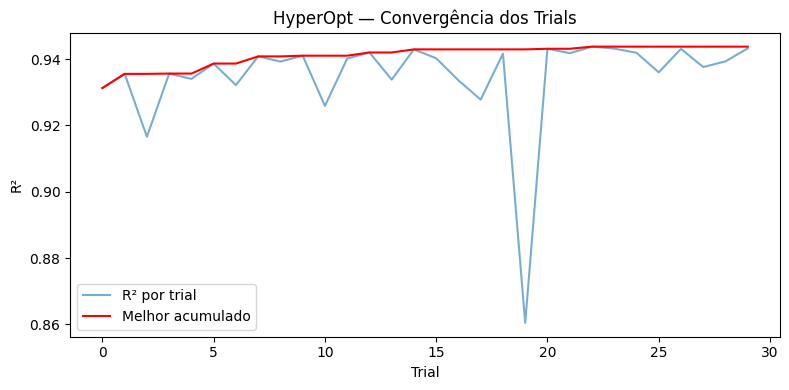

In [ ]:
import matplotlib.pyplot as plt
from hyperopt import STATUS_OK, STATUS_FAIL


def objective_hyperopt(params):
    model = CatBoostRegressor(
        iterations=int(params['iterations']),
        learning_rate=params['learning_rate'],
        depth=int(params['depth']),
        l2_leaf_reg=params['l2_leaf_reg'],
        verbose=0,
        random_state=42
    )
    #   Retorno correto: minimizar negativo do R²
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring='r2')
    return {'loss': -scores.mean(), 'status': STATUS_OK}

space = {
    'iterations':    hp.quniform('iterations', 100, 600, 50),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.3)),
    'depth':         hp.quniform('depth', 3, 10, 1),
    'l2_leaf_reg':   hp.uniform('l2_leaf_reg', 1, 10),
}

trials = Trials()
best_hyperopt = fmin(
    fn=objective_hyperopt,
    space=space,
    algo=tpe.suggest,
    max_evals=30,
    trials=trials,
    verbose=False
)

best_cat = CatBoostRegressor(
    iterations=int(best_hyperopt['iterations']),
    learning_rate=best_hyperopt['learning_rate'],
    depth=int(best_hyperopt['depth']),
    l2_leaf_reg=best_hyperopt['l2_leaf_reg'],
    verbose=0
)
best_cat.fit(X_train, y_train)
r2_hyperopt = r2_score(y_test, best_cat.predict(X_test))

print(f'  Melhores parâmetros: {best_hyperopt}')
print(f'   R² (teste):         {r2_hyperopt:.4f}')

# Curva de convergência
losses = [-t['result']['loss'] for t in trials.trials]
plt.figure(figsize=(8, 4))
plt.plot(losses, alpha=0.6, label='R² por trial')
plt.plot(pd.Series(losses).cummax(), color='red', label='Melhor acumulado')
plt.xlabel('Trial')
plt.ylabel('R²')
plt.title('HyperOpt — Convergência dos Trials')
plt.legend()
plt.tight_layout()
plt.show()

Feature Selection Integrada ao Tuning

> **Por que combinar Feature Selection com Tuning?**  
> Features irrelevantes ou redundantes prejudicam modelos de duas formas:
> 1. Aumentam a complexidade desnecessariamente (overfitting)
> 2. O tuning de hiperparâmetros pode compensar ruído em vez de aprender o sinal
>
> Ao integrar Feature Selection no pipeline de tuning, garantimos que o modelo otimize **o conjunto certo de features** — não todas ao mesmo tempo.
>
> **Métodos abordados:**
> - **SelectKBest** (filtro estatístico)
> - **SelectFromModel** (baseado em importância do modelo)
> - **RFECV** (eliminação recursiva com validação cruzada)
> - **Pipeline Sklearn** com feature selection + tuning

MÉTODO 1: SelectKBest (Informação Mútua)

 Scores de Informação Mútua (maior = mais relevante):
fertilizante_kg_ha     0.5229
chuva_mm               0.1914
temperatura_C          0.0230
uso_pesticidas_L_ha    0.0223
qualidade_solo         0.0000
horas_sol_ano          0.0000
dtype: float64


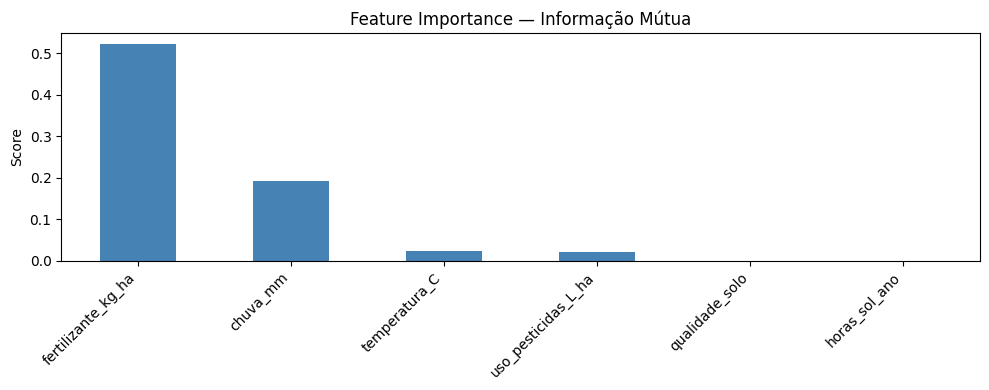

In [ ]:
# ─── Método 1: SelectKBest ────────────────────────────────────────────────────
print('=' * 60)
print('MÉTODO 1: SelectKBest (Informação Mútua)')
print('=' * 60)

selector_kbest = SelectKBest(score_func=mutual_info_regression, k='all')
selector_kbest.fit(X_train, y_train)

feature_scores = pd.Series(
    selector_kbest.scores_,
    index=X_train.columns
).sort_values(ascending=False)

print('\n Scores de Informação Mútua (maior = mais relevante):')
print(feature_scores.round(4))

plt.figure(figsize=(10, 4))
feature_scores.plot(kind='bar', color='steelblue')
plt.title('Feature Importance — Informação Mútua')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

MÉTODO 2: RFECV (Eliminação Recursiva com Cross-Validation)

Número ótimo de features: 4
Features selecionadas: ['chuva_mm', 'temperatura_C', 'fertilizante_kg_ha', 'qualidade_solo']


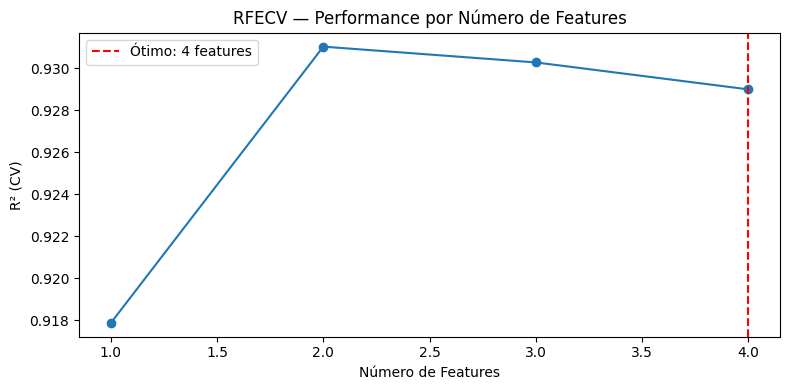

In [ ]:
# ─── Método 2: RFECV — Eliminação Recursiva com CV ───────────────────────────
print('=' * 60)
print('MÉTODO 2: RFECV (Eliminação Recursiva com Cross-Validation)')
print('=' * 60)

rfecv = RFECV(
    estimator=RandomForestRegressor(n_estimators=100, random_state=42),
    step=1,
    cv=3,
    scoring='r2',
    min_features_to_select=3,
    n_jobs=-1
)
rfecv.fit(X_train, y_train)

features_selecionadas = X_train.columns[rfecv.support_].tolist()
print(f'\nNúmero ótimo de features: {rfecv.n_features_}')
print(f'Features selecionadas: {features_selecionadas}')

# Curva de performance vs. número de features
plt.figure(figsize=(8, 4))
n_features_range = range(1, len(rfecv.cv_results_['mean_test_score']) + 1)
plt.plot(n_features_range, rfecv.cv_results_['mean_test_score'], marker='o')
plt.axvline(rfecv.n_features_, color='red', linestyle='--', label=f'Ótimo: {rfecv.n_features_} features')
plt.xlabel('Número de Features')
plt.ylabel('R² (CV)')
plt.title('RFECV — Performance por Número de Features')
plt.legend()
plt.tight_layout()
plt.show()

X_train_sel = X_train[features_selecionadas]
X_test_sel  = X_test[features_selecionadas]

In [ ]:

# ─── Método 3: Pipeline Feature Selection + Optuna ────────────────────────────
print('=' * 60)
print('MÉTODO 3: Feature Selection + Tuning via Optuna')
print('=' * 60)

def objective_feat_select(trial):
    #  Tuning do número de features também é um hiperparâmetro!
    k = trial.suggest_int('k_features', 4, X_train.shape[1])

    params = {
        'n_estimators':  trial.suggest_int('n_estimators', 50, 300),
        'max_depth':     trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':     trial.suggest_float('subsample', 0.5, 1.0),
    }

    # Pipeline: SelectKBest → XGBoost
    pipeline = Pipeline([
        ('selector', SelectKBest(mutual_info_regression, k=k)),
        ('model',    XGBRegressor(**params, random_state=42, verbosity=0))
    ])

    scores = cross_val_score(pipeline, X_train, y_train, cv=3, scoring='r2')
    return scores.mean()

study_fs = optuna.create_study(direction='maximize')
study_fs.optimize(objective_feat_select, n_trials=40, show_progress_bar=True)

print(f'\n Melhor número de features: {study_fs.best_params["k_features"]}')
print(f'   Melhores parâmetros: {study_fs.best_params}')
print(f'   Melhor R² (CV):     {study_fs.best_value:.4f}')

# Treinar modelo final com os melhores parâmetros
best_k = study_fs.best_params.pop('k_features')
pipeline_final = Pipeline([
    ('selector', SelectKBest(mutual_info_regression, k=best_k)),
    ('model',    XGBRegressor(**study_fs.best_params, random_state=42, verbosity=0))
])
pipeline_final.fit(X_train, y_train)
r2_feat_select = r2_score(y_test, pipeline_final.predict(X_test))
print(f'   R² (teste):         {r2_feat_select:.4f}')

[I 2026-03-26 18:28:18,417] A new study created in memory with name: no-name-7b9d3425-5b3e-4c2f-abb1-67c909c71d99


MÉTODO 3: Feature Selection + Tuning via Optuna


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-03-26 18:28:24,187] Trial 0 finished with value: 0.9135472234316087 and parameters: {'k_features': 5, 'n_estimators': 260, 'max_depth': 3, 'learning_rate': 0.07370024665008845, 'subsample': 0.8960687819437564}. Best is trial 0 with value: 0.9135472234316087.
[I 2026-03-26 18:28:34,900] Trial 1 finished with value: 0.8966286015931907 and parameters: {'k_features': 4, 'n_estimators': 148, 'max_depth': 15, 'learning_rate': 0.0756730204719255, 'subsample': 0.5843448290858214}. Best is trial 0 with value: 0.9135472234316087.
[I 2026-03-26 18:28:37,608] Trial 2 finished with value: 0.8875602283923163 and parameters: {'k_features': 6, 'n_estimators': 68, 'max_depth': 14, 'learning_rate': 0.026112190599998305, 'subsample': 0.5291095268837718}. Best is trial 0 with value: 0.9135472234316087.
[I 2026-03-26 18:28:49,337] Trial 3 finished with value: 0.8954038620884545 and parameters: {'k_features': 4, 'n_estimators': 286, 'max_depth': 13, 'learning_rate': 0.054488416088433425, 'subsample'

Data Drift — Detecção e Impacto no Pipeline

> **O que é Data Drift?**  
> Data Drift ocorre quando a **distribuição dos dados muda ao longo do tempo** entre treino e produção. Isso pode degradar silenciosamente a performance de modelos sem que nenhum erro explícito apareça.
>
> **Tipos:**
> - **Feature Drift (Covariate Shift):** P(X) muda, mas P(Y|X) mantém
> - **Label Drift:** P(Y) muda (raro em produção antes de ver as labels)
> - **Concept Drift:** P(Y|X) muda — o próprio relacionamento entre features e target muda
>
> **Testes estatísticos usados:**
> - **KS Test (Kolmogorov-Smirnov):** compara distribuições de features numéricas
> - **Chi² Test:** para features categóricas
> - **PSI (Population Stability Index):** mede estabilidade da distribuição (padrão de risco em crédito)
>
> **Estratégias de mitigação:**
> - Retreinamento periódico com dados recentes
> - Importância de features ponderada por tempo
> - Adição de dados de produção ao conjunto de treino

In [ ]:
df.sample(4)

,chuva_mm,temperatura_C,fertilizante_kg_ha,qualidade_solo,horas_sol_ano,uso_pesticidas_L_ha,produtividade_sacos_ha
1801,234.377090,16.410713,68.457819,8.535160,1017.439902,6.999594,160.552011
1190,66.837650,30.069442,133.983580,6.673608,2256.344102,5.594021,184.366013
1817,242.305787,31.392497,191.080595,7.302757,1732.507216,0.622437,305.729657
251,146.274432,17.307893,76.096610,6.701818,2167.829538,5.170147,155.793822


In [ ]:
# ─── Simulação de Data Drift ──────────────────────────────────────────────────
np.random.seed(42)

# Simular dados de "produção" com drift em algumas features
X_producao = X_test.copy()

# Injetar drift artificial em 3 features
features_com_drift = ['chuva_mm', 'temperatura_C', 'fertilizante_kg_ha']
for feat in features_com_drift:
    shift = X_train[feat].std() * 0.7  # drift de 0.7 desvios padrão
    X_producao[feat] = X_producao[feat] + shift + np.random.normal(0, shift * 0.2, len(X_producao))

print('  Dados de produção com drift simulado criados!')
print(f'   Shape: {X_producao.shape}')

  Dados de produção com drift simulado criados!
   Shape: (600, 6)


In [ ]:
r2_feat_select = r2_score(y_test, pipeline_final.predict(X_producao))
print(f'   R² (teste):         {r2_feat_select:.4f}')

   R² (teste):         -0.0352
